In [1]:
%%capture
!pip uninstall qunum -y
!pip install /Users/matt/qunum

In [5]:
import qunum.numerical as qn
from qunum.jupyter_tools.plotting import PlotIt
from qunum.numerical.physics.quantum.heisenberg.bbgky_truncation.bbgky import BBGKYDecoupling as BBGKY
import os, torch
import time
import tqdm
def mk_obj(N:int, n:int,**kwargs)->BBGKY:
    print(N,n)
    a = dict(Nsteps= int(4500), u0 = 10_000*1e2, tgt_u0 = 5, debug=False, load_data=False, dp = .1, p0 = torch.tensor(1e10), method = 'gaussrk', adaptive_epsilon=5e-3, dt  = 1e-2, adaptive_time_step=True, r0_Rv = 7.5, p_start_f = .1)
    a.update(kwargs)
    print(a, kwargs)
    return BBGKY(
        N=N, n=n, 
        data_storage_loc=os.path.join('BBGKYSims', f'BBGKY_{N}-{n}'),
        **a
    )
from qunum.numerical.mathematics.algebra import gen_clock
A = gen_clock(3)
A

(tensor([[ 1.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
         [ 0.0000+0.0000j, -0.5000+0.8660j,  0.0000+0.0000j],
         [ 0.0000+0.0000j,  0.0000+0.0000j, -0.5000-0.8660j]],
        dtype=torch.complex128),
 tensor([[0.+0.j, 1.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 1.+0.j],
         [1.+0.j, 0.+0.j, 0.+0.j]], dtype=torch.complex128))

In [35]:
O = mk_obj(100,2, Nsteps = 5_000, renorm = True, angular_dependence = 'random_uniform')

for o in tqdm.tqdm(O):
    pass
    

100 2
{'Nsteps': 5000, 'u0': 1000000.0, 'tgt_u0': 5, 'debug': False, 'load_data': False, 'dp': 0.1, 'p0': tensor(1.0000e+10), 'method': 'gaussrk', 'adaptive_epsilon': 0.005, 'dt': 0.01, 'adaptive_time_step': True, 'r0_Rv': 7.5, 'p_start_f': 0.1, 'renorm': True, 'angular_dependence': 'random_uniform'} {'Nsteps': 5000, 'renorm': True, 'angular_dependence': 'random_uniform'}


2it [00:05,  2.82s/it]


KeyboardInterrupt: 

In [29]:
self = O
pMag = self.p.pow(2).sum(-1).sqrt()
pHat = self.p/self.pMag[:,None]
(self.Pi.to(torch.float64)- (1 - ((self.p[:,None]*self.p[None]).sum(-1))/(pMag[:,None]*pMag[None])).real).pow(2).sum()

tensor(8.0628e-13, dtype=torch.float64)

20 2
{'Nsteps': 5000, 'u0': 1000000.0, 'tgt_u0': 5, 'debug': True, 'load_data': True, 'dp': 0.1, 'p0': tensor(1.0000e+10), 'method': 'gaussrk', 'adaptive_epsilon': 0.005, 'dt': 0.01, 'adaptive_time_step': True, 'r0_Rv': 7.5, 'p_start_f': 0.1, 'renorm': True, 'angular_dependence': 'random_uniform'} {'Nsteps': 5000, 'renorm': True, 'angular_dependence': 'random_uniform', 'load_data': True, 'debug': True}
Loading Tensors


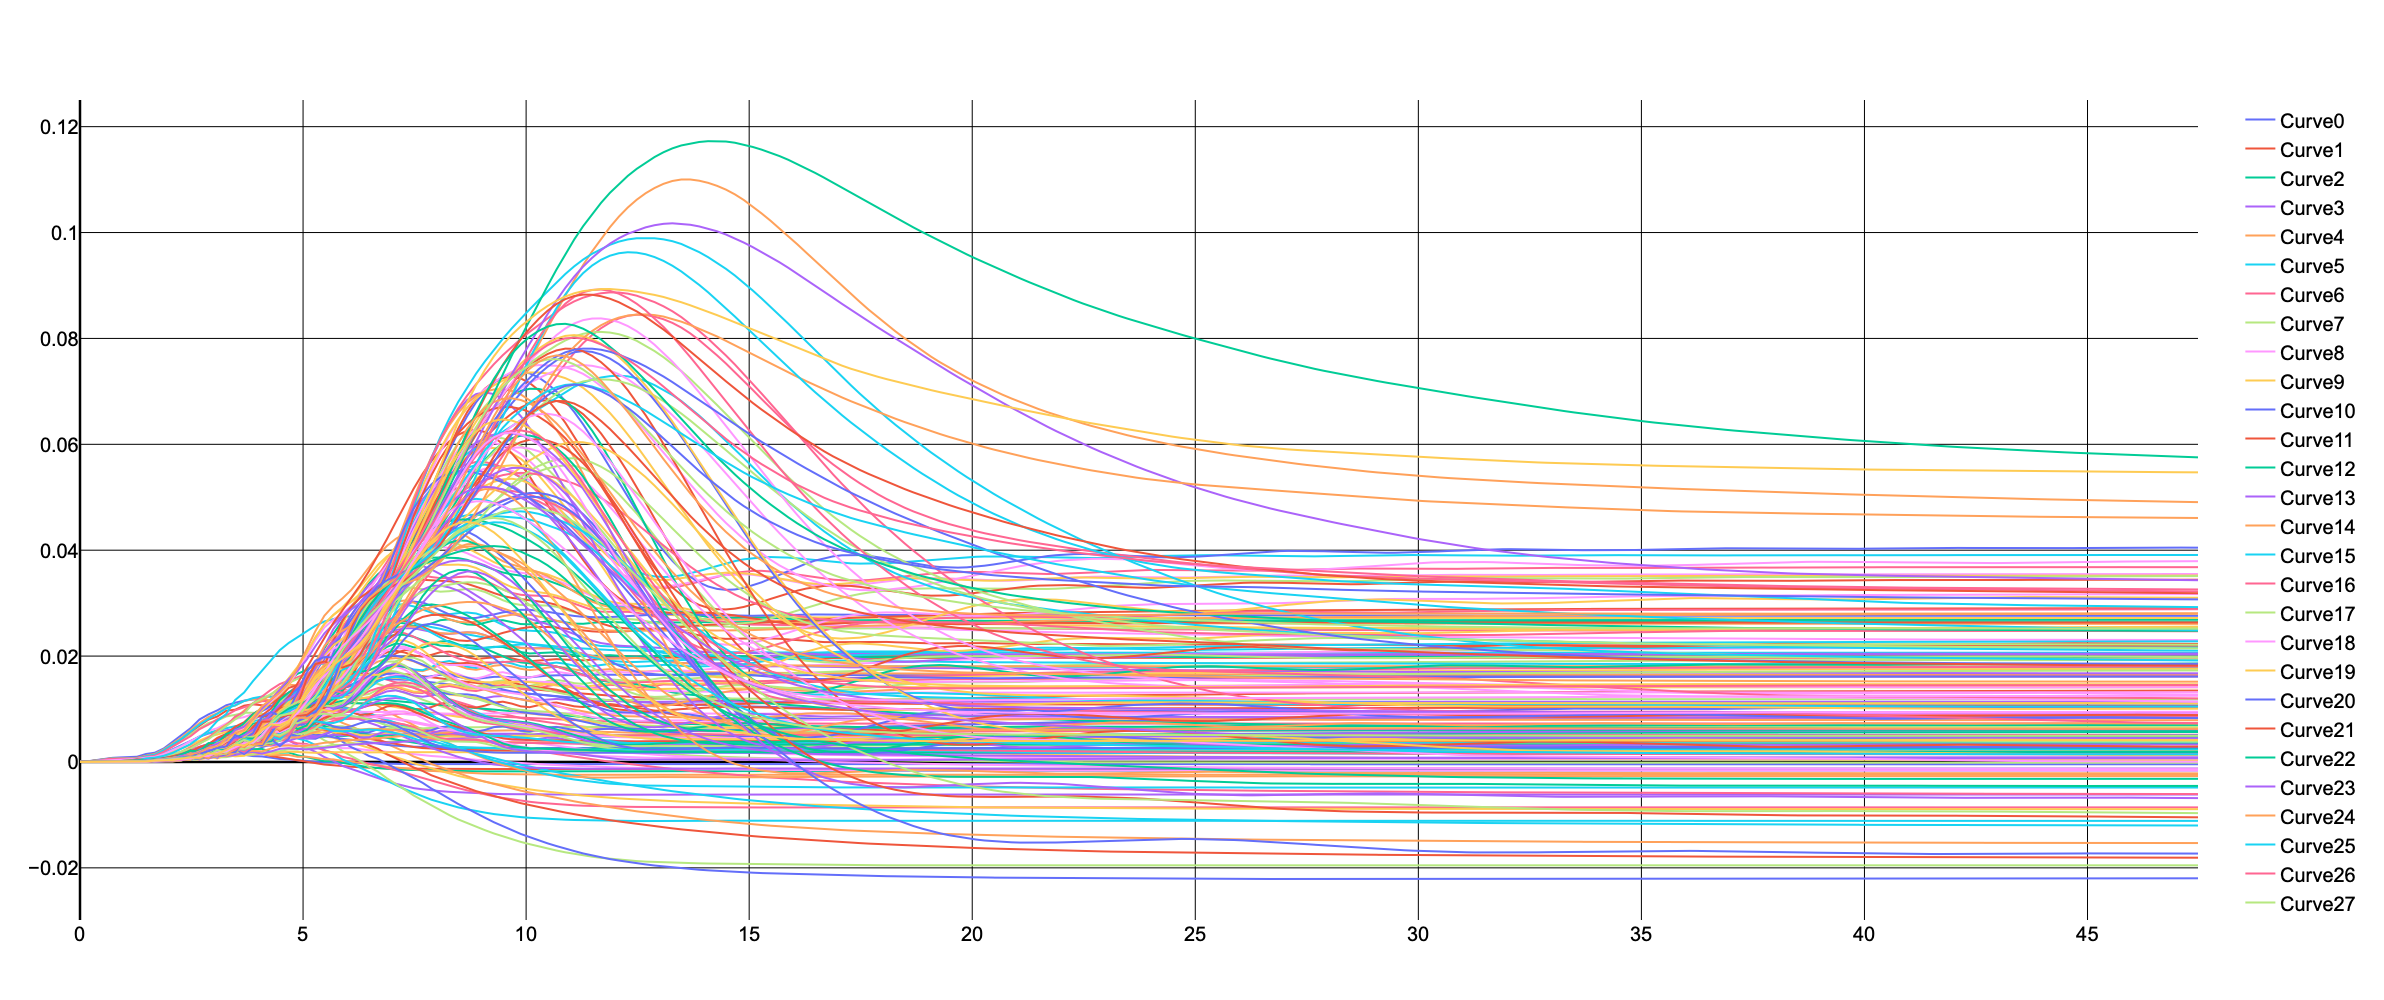

In [32]:
O2 = mk_obj(20,2, Nsteps = 5_000, renorm = True, angular_dependence = 'random_uniform', load_data = True, debug = True)
plt = PlotIt()
t = torch.arange(0, 5_000, step = 20)
S = O2.mutualInformation(t = t)
plt.extend_data(*(dict(x = O.dt.t[t], y = S[:,A] )for A in range(S.shape[1])))
plt.show()

In [33]:
from torch import zeros, diag_embed,exp,pi, arange, tensor, complex128
N = 3

X, Z


(tensor([[0., 1., 0.],
         [0., 0., 1.],
         [1., 0., 0.]]),
 tensor([[ 1.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
         [ 0.0000+0.0000j, -0.5000+0.8660j,  0.0000+0.0000j],
         [ 0.0000+0.0000j,  0.0000+0.0000j, -0.5000-0.8660j]],
        dtype=torch.complex128))

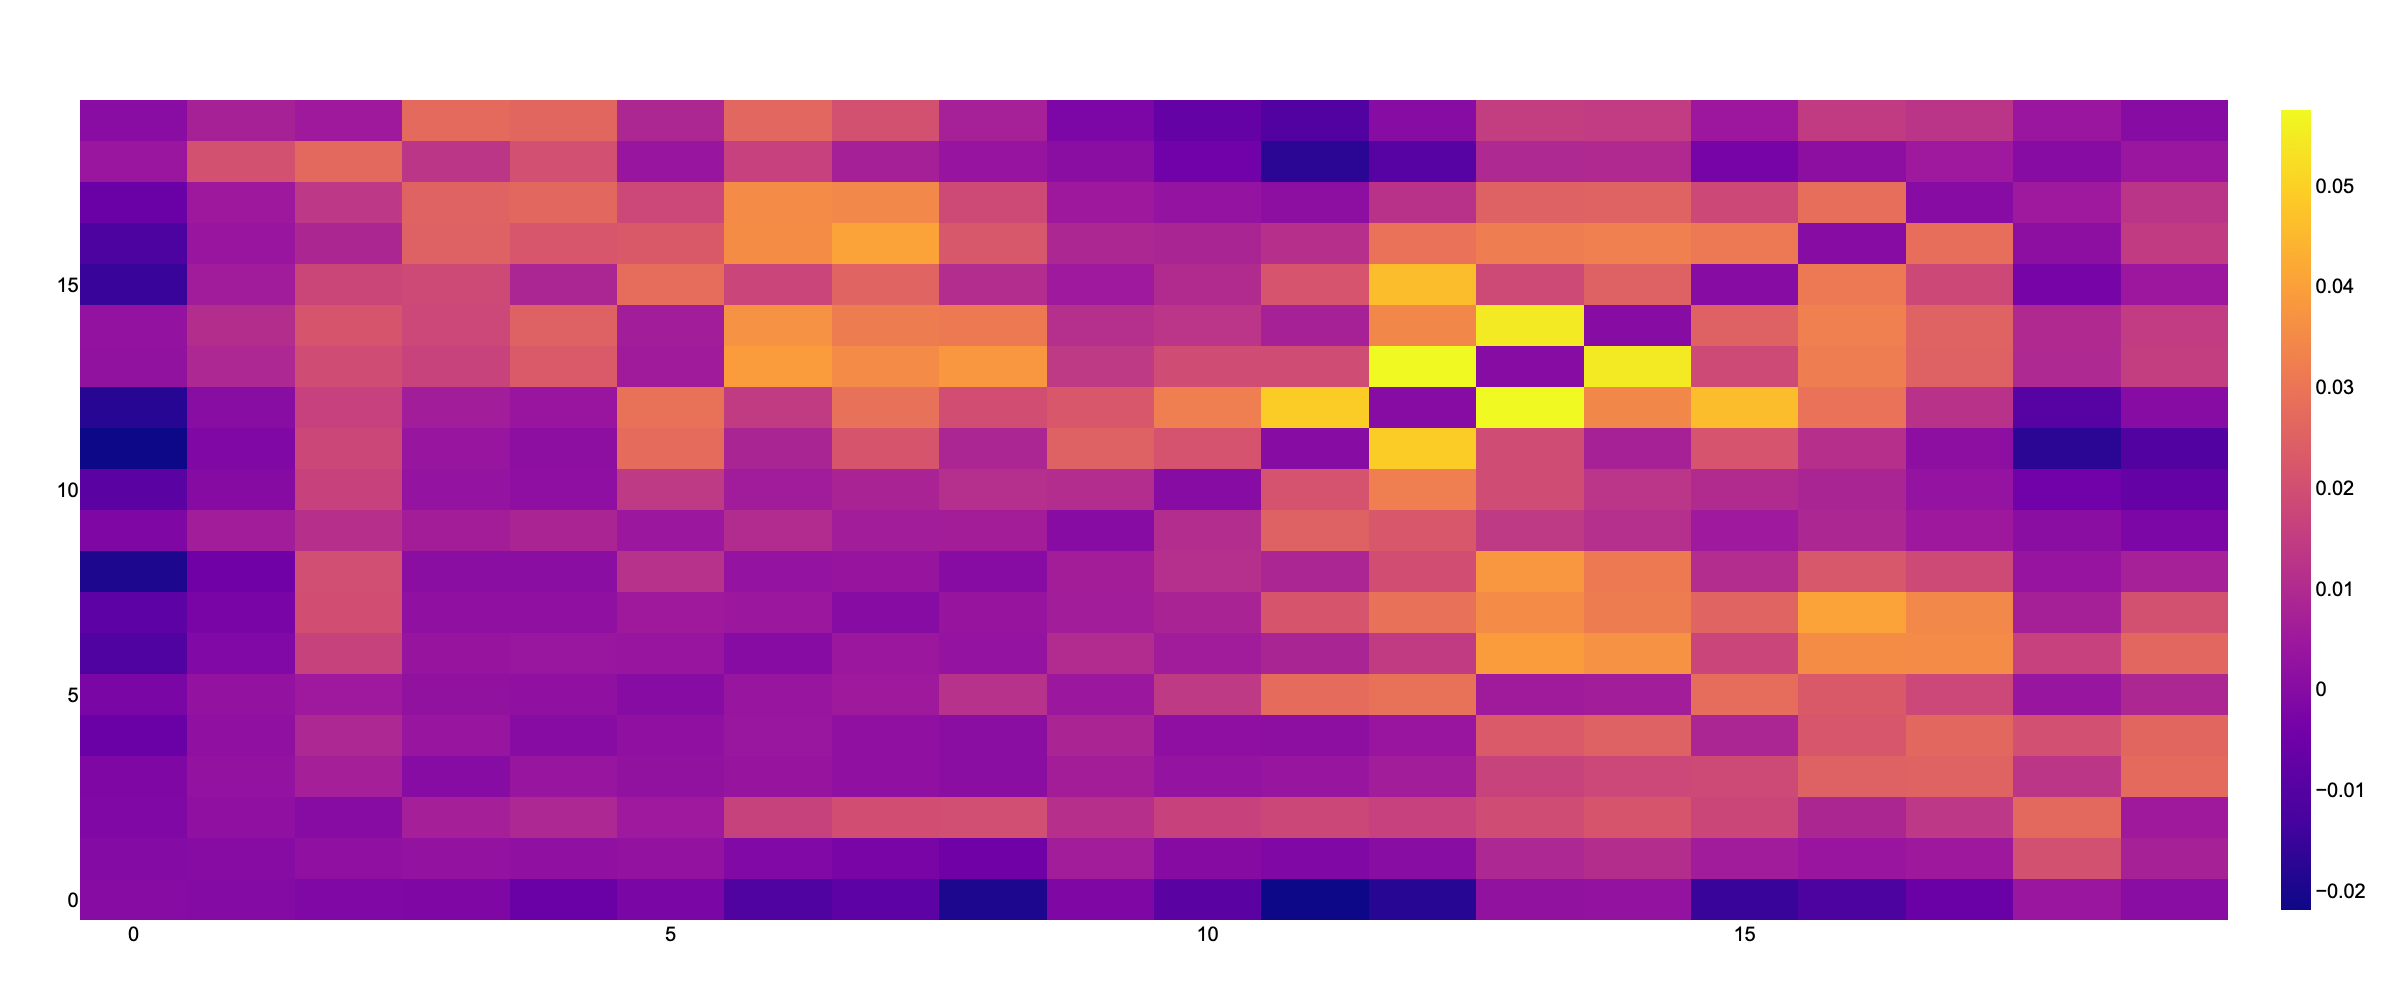

In [34]:
plt.reset()
I = torch.zeros_like(O.Pi)
V, Mp = O.mutualInformation(t =[-1], ret_map=True )
I[Mp['A'].to_torch(), Mp['B'].to_torch()] = V.to(O.Pi.dtype)
I[Mp['B'].to_torch(), Mp['A'].to_torch()] = V.to(O.Pi.dtype)
plt.add_data(type = 'heatmap', x =torch.arange(O.N), y = torch.arange(O.N), z = I)
plt.show()


In [7]:
N = 10
phi = 2*torch.pi*torch.rand(N)
t = torch.arccos(2*torch.rand(N) - 1)
phat = torch.stack([t.sin()*phi.cos(),t.sin()*phi.sin(), t.cos()]).T


torch.Size([10, 3])

In [ ]:
torch.diag_embed